<a href="https://colab.research.google.com/github/auroraguorui-cmyk/llm-learning/blob/main/stage0/pytorch_warmup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, torch
print(sys.version)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
torch: 2.11.0+cu130
cuda: True
Tesla T4


In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x
y.backward()
print(x.grad)

tensor(14.)


In [ ]:
A = torch.randn(3, 4)
b = torch.tensor([1.0, 2.0, 3.0, 4.0])
C = A + b
print(A.shape, b.shape, C.shape)
print(C)

In [ ]:
import torch

xs = torch.linspace(-1, 1, 20)
ys = 3 * xs - 2

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(100):
    pred = w * xs + b
    loss = ((pred - ys) ** 2).mean()
    loss.backward()

    # TODO 1: 更新 w、b
    with torch.no_grad():
      w -= lr * w.grad
      b -= lr * b.grad
    # TODO 2: 清零 w.grad、b.grad
    w.grad.zero_()
    b.grad.zero_()
    # TODO 3: 每 20 步打印 step、loss、w、b

    if step % 20 == 0:
      print("step: ", step)
      print("loss: ", loss)
      print("w: ", w)
      print("b: ", b)

print("final:", w.item(), b.item())

step:  0
loss:  tensor(7.3158, grad_fn=<MeanBackward0>)
w:  tensor(0.2211, requires_grad=True)
b:  tensor(-0.4000, requires_grad=True)
step:  20
loss:  tensor(0.1558, grad_fn=<MeanBackward0>)
w:  tensor(2.3987, requires_grad=True)
b:  tensor(-1.9816, requires_grad=True)
step:  40
loss:  tensor(0.0073, grad_fn=<MeanBackward0>)
w:  tensor(2.8699, requires_grad=True)
b:  tensor(-1.9998, requires_grad=True)
step:  60
loss:  tensor(0.0003, grad_fn=<MeanBackward0>)
w:  tensor(2.9719, requires_grad=True)
b:  tensor(-2.0000, requires_grad=True)
step:  80
loss:  tensor(1.5923e-05, grad_fn=<MeanBackward0>)
w:  tensor(2.9939, requires_grad=True)
b:  tensor(-2.0000, requires_grad=True)
final: 2.99857759475708 -1.999999761581421


In [1]:
import torch
import torch.nn as nn

# 数据：x 在 [-3.14, 3.14]，y = sin(x)
xs = torch.linspace(-3.14, 3.14, 100).reshape(-1, 1)
ys = torch.sin(xs)

# 一个两层小网络：1 -> 64 -> 1
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1),
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for step in range(1000):
    pred = model(xs)
    loss = loss_fn(pred, ys)
    # TODO 1: 清零梯度（这次用 optimizer 的方法）
    optimizer.zero_grad()

    # TODO 2: backward
    loss.backward()
    # TODO 3: 让 optimizer 更新参数
    optimizer.step()
    if step % 200 == 0:
        print(step, loss.item())

print("final loss:", loss.item())

0 0.6480553150177002
200 0.0026807510294020176
400 0.00026474808692000806
600 7.552930037491024e-05
800 2.0682231479440816e-05
final loss: 6.891672455822118e-06


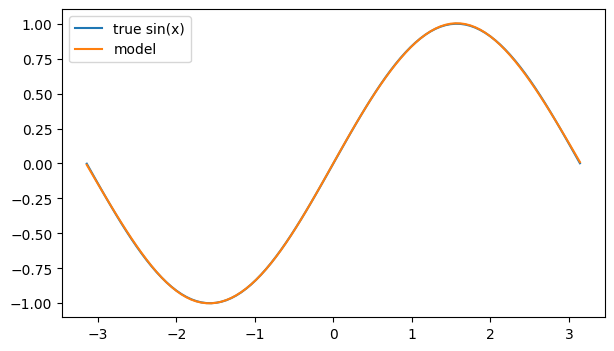

In [2]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pred = model(xs)

plt.figure(figsize=(7, 4))
plt.plot(xs.numpy(), ys.numpy(), label="true sin(x)")
plt.plot(xs.numpy(), pred.numpy(), label="model")
plt.legend()
plt.show()